In [67]:
import warnings

warnings.filterwarnings('ignore')
import seaborn as sns
import pandas as pd
df = sns.load_dataset('titanic')
df.to_csv("titanic.csv", index=False)

In [68]:
df = pd.read_csv('C:/Users/NIRAJ/Python/titanic.csv')

In [69]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [70]:
df['sibsp'].value_counts()

sibsp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

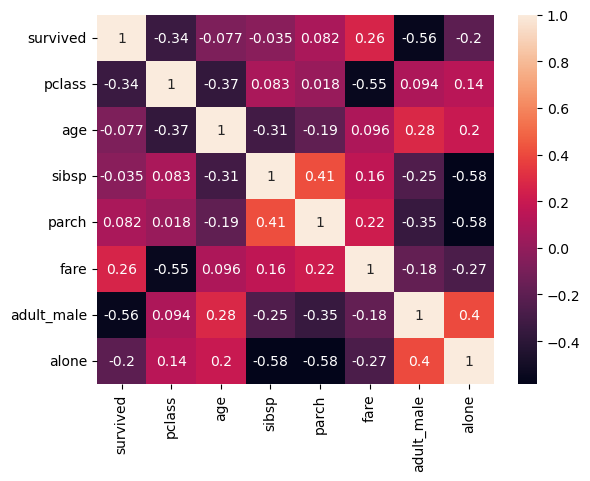

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.show()

In [72]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [73]:
df.isnull().any(axis=1)

0       True
1      False
2       True
3      False
4       True
       ...  
886     True
887    False
888     True
889    False
890     True
Length: 891, dtype: bool

In [74]:
df['age'].fillna(df['age'].mean(),inplace=True)

In [75]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [76]:
df = df.drop(['deck'],axis=1)

In [77]:
df.dropna().reset_index(drop=True)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,Southampton,no,True
885,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,Southampton,yes,True
886,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,Southampton,no,False
887,1,1,male,26.000000,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [78]:
X = df.drop(['survived','who','embarked','alive'],axis=1)
y = df['survived']

In [79]:
print(type(X))
print(type(y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [80]:
X

,pclass,sex,age,sibsp,parch,fare,class,adult_male,embark_town,alone
0,3,male,22.000000,1,0,7.2500,Third,True,Southampton,False
1,1,female,38.000000,1,0,71.2833,First,False,Cherbourg,False
2,3,female,26.000000,0,0,7.9250,Third,False,Southampton,True
3,1,female,35.000000,1,0,53.1000,First,False,Southampton,False
4,3,male,35.000000,0,0,8.0500,Third,True,Southampton,True
...,...,...,...,...,...,...,...,...,...,...
886,2,male,27.000000,0,0,13.0000,Second,True,Southampton,True
887,1,female,19.000000,0,0,30.0000,First,False,Southampton,True
888,3,female,29.699118,1,2,23.4500,Third,False,Southampton,False
889,1,male,26.000000,0,0,30.0000,First,True,Cherbourg,True


In [121]:
from sklearn.model_selection import train_test_split,cross_val_score
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=10)

In [122]:
X_train

,pclass,sex,age,sibsp,parch,fare,class,adult_male,embark_town,alone
578,3,female,29.699118,1,0,14.4583,Third,False,Cherbourg,False
323,2,female,22.000000,1,1,29.0000,Second,False,Southampton,False
654,3,female,18.000000,0,0,6.7500,Third,False,Queenstown,True
157,3,male,30.000000,0,0,8.0500,Third,True,Southampton,True
692,3,male,29.699118,0,0,56.4958,Third,True,Southampton,True
...,...,...,...,...,...,...,...,...,...,...
369,1,female,24.000000,0,0,69.3000,First,False,Cherbourg,True
320,3,male,22.000000,0,0,7.2500,Third,True,Southampton,True
527,1,male,29.699118,0,0,221.7792,First,True,Southampton,True
125,3,male,12.000000,1,0,11.2417,Third,False,Cherbourg,False


In [123]:
from sklearn.preprocessing import LabelEncoder
le1= LabelEncoder()
le2= LabelEncoder()
le3= LabelEncoder()

In [124]:
X_train['sex']=le1.fit_transform(X_train['sex'])
X_train['adult_male']=le2.fit_transform(X_train['adult_male'])
X_train['alone']=le3.fit_transform(X_train['alone'])

###
X_test['sex']=le1.transform(X_test['sex'])
X_test['adult_male']=le2.transform(X_test['adult_male'])
X_test['alone']=le3.transform(X_test['alone'])

In [125]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

#categorical_cols = ['class','embark_town']=[6,8]

ct = ColumnTransformer(
    transformers=[
        ('onehot',
         OneHotEncoder(drop='first', sparse_output=False),
         [6,8])
    ],
    remainder='passthrough'
)

X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

In [126]:
print(X_train[:5])

[[ 0.          1.          0.          0.          0.          3.
   0.         29.69911765  1.          0.         14.4583      0.
   0.        ]
 [ 1.          0.          0.          1.          0.          2.
   0.         22.          1.          1.         29.          0.
   0.        ]
 [ 0.          1.          1.          0.          0.          3.
   0.         18.          0.          0.          6.75        0.
   1.        ]
 [ 0.          1.          0.          1.          0.          3.
   1.         30.          0.          0.          8.05        1.
   1.        ]
 [ 0.          1.          0.          1.          0.          3.
   1.         29.69911765  0.          0.         56.4958      1.
   1.        ]]


In [127]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [128]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [129]:
score = accuracy_score(y_test,y_pred)
print(score)
cm = confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

0.8430493273542601
[[130  17]
 [ 18  58]]
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       147
           1       0.77      0.76      0.77        76

    accuracy                           0.84       223
   macro avg       0.83      0.82      0.82       223
weighted avg       0.84      0.84      0.84       223



In [130]:
model = LogisticRegression()
penalty =['l1', 'l2', 'elasticnet']
c_values = [100,10,1.0,0.1,0.01]
solver = ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']
params = dict(penalty=penalty,C= c_values,solver=solver)

In [131]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold()

In [132]:
#Grid Search CV
from sklearn.model_selection import GridSearchCV
grid =GridSearchCV(estimator=model,param_grid=params,scoring='accuracy',cv=cv,n_jobs=-1)

In [133]:
grid.fit(X_train,y_train)
grid.best_score_

np.float64(0.8069464706542476)

In [134]:
y_pred = grid.predict(X_test)

In [135]:
score = accuracy_score(y_test,y_pred)
print(score)
cm = confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

0.8430493273542601
[[133  14]
 [ 21  55]]
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       147
           1       0.80      0.72      0.76        76

    accuracy                           0.84       223
   macro avg       0.83      0.81      0.82       223
weighted avg       0.84      0.84      0.84       223



In [136]:
grid.best_params_

{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}

In [137]:
#Randomized SearchCV
from sklearn.model_selection import RandomizedSearchCV

model = LogisticRegression()
randomcv = RandomizedSearchCV(estimator=model,param_distributions = params,cv=5,scoring='accuracy')

In [138]:
randomcv.fit(X_train,y_train)
randomcv.predict(X_test)
randomcv.best_score_

np.float64(0.8054314891706879)

In [139]:
score = accuracy_score(y_test,y_pred)
print(score)
cm = confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

0.8430493273542601
[[133  14]
 [ 21  55]]
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       147
           1       0.80      0.72      0.76        76

    accuracy                           0.84       223
   macro avg       0.83      0.81      0.82       223
weighted avg       0.84      0.84      0.84       223



In [140]:
randomcv.best_params_

{'solver': 'newton-cg', 'penalty': 'l2', 'C': 0.1}